In [12]:
data_folder="../Data/"

import sys
import os

sys.path.append(os.path.abspath("../Codes"))

sys.path.append(os.path.abspath("../_Deep_Learning"))

from Utils import freq_filter, windowize,  RegionWiseStandardizer

from BCI_Library import read_subject, saveresults_pickle, compute_welch
from BCI_Library import  train_single_model,select_regions_Cohen_effect_size, build_compiled_mlp

2026-03-16 18:29:11.209962: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 18:29:11.286093: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 18:29:12.649065: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [79]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix

# del train_single_model_investigate
def train_single_model_investigate(data_features, labels, train_idx, val_idx, method, 
                 scaler=StandardScaler, seed=224, return_predictions=True,
                 verbose=False, fit_kwargs={}, n_windows=1):
    
    X_train, X_val = data_features[train_idx], data_features[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]
    
    # StandardScaler:
    if scaler is not None:
        scaler_instance = scaler()
        X_train_scaled = scaler_instance.fit_transform(X_train)
        X_val_scaled   = scaler_instance.transform(X_val)

    # Model instance
    try:
        model = method(random_state=seed)
    except:
        try:
            model = method()
        except:
            model = method
    is_keras_model = isinstance(model, tf.keras.Model)

    if is_keras_model:
        model.fit(X_train_scaled, y_train,validation_data=(X_val_scaled, y_val), **fit_kwargs)
    else:
        model.fit(X_train_scaled, y_train)
    acc = {}
    confusion_mat = {}
    labels_preds = {}
    for _ in range(n_windows):
        y_pred = model.predict(X_val_scaled[_::n_windows])
    
        if is_keras_model:
            y_pred = (y_pred > 0.5).astype(int).ravel()

        # Accuracy   # Confusion matrix
        acc["window_"+str(_)] = accuracy_score(y_val[_::n_windows], y_pred)
        confusion_mat["window_"+str(_)] = confusion_matrix(y_val[_::n_windows], y_pred)
        labels_preds["window_"+str(_)] = {"y_true":y_val[_::n_windows], "y_pred":y_pred}
        print(len(y_val[_::n_windows]))
    if return_predictions:
        return acc, confusion_mat, model, labels_preds
    return acc, confusion_mat, model

# Region Agnostic - test on the same subject - PowerSpectra

In [72]:
import os
import sys
import tensorflow.keras as keras

# To be changed
Tutti_soggetti = [8]
DataType = "EEG"
CNN_o_Autoencoder = "Autoencoder" # Autoencoder, # CNN
model_path_4 = "2026-03-05-11_09_47_Encoder_timeseries_Decoder_spectra_log_simpleNormalization" + "/"

# Fixed
model_path_1 = f"../_Deep_Learning/Models_trained/Subject_"
# model path 2 = f"{subject_index}/"
# model path 2.5 = f"{DataType}/"
model_path_3 = f"{CNN_o_Autoencoder}" + ("s/" if CNN_o_Autoencoder=="Autoencoder" else "/")

lib_path = model_path_1 + f"{Tutti_soggetti[0]}/" + f"{DataType}/" + model_path_3 + model_path_4

sys.path.append(os.path.abspath(lib_path))
try:
    del MultiTaskModel_PowerSpectra
    print("ho resettato MultiTaskModel")
except:
    print("non ho resettato MultiTaskModel")

try :
    from _Backup_Library import MultiTaskModel_PowerSpectra
except:
    from Deep_Library_BCI import MultiTaskModel_PowerSpectra
    raise Exception("Non ho caricato dal backup, controlla bene se è quello che vuoi")


use_GRU = True if "GRU" in model_path_4.replace("/","").split("_") else False

if CNN_o_Autoencoder == "CNN":
    model = MultiTaskModel_PowerSpectra(input_shape=(256,1), output_shape=24, use_classifier=True, use_decoder=False, use_GRU=use_GRU)
if CNN_o_Autoencoder == "Autoencoder":
    try:
        model = MultiTaskModel_PowerSpectra(input_shape=(256,1), output_shape=24, use_classifier=False, use_decoder=True, use_GRU=use_GRU)
    except:
        model = MultiTaskModel_PowerSpectra(input_shape=(256,1), output_shape=24, use_classifier=False, use_decoder=True)
if CNN_o_Autoencoder == "SupervisedAutoencoder":
    try:
        model = MultiTaskModel_PowerSpectra(input_shape=(256,1), output_shape=24, use_classifier=True, use_decoder=True, use_GRU=use_GRU)
    except:
        model = MultiTaskModel_PowerSpectra(input_shape=(256,1), output_shape=24, use_classifier=True, use_decoder=True)


model.build(input_shape=(256,1))

ho resettato MultiTaskModel


## Per fold region selection

In [73]:
def compute_power_spectra(data_2_MI, data_2_Rest):
    sfreq = 250
    miff = [8,12]
    maff = [12,30]

    WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                        kargs_welch={"fmin":miff[0], "fmax":maff[-1]})

    return WMI, WRe

import numpy as np
def selezione_cohen(WRe, WMI, train_idx, num_best_ROIs):
    training_index_Re = train_idx[np.where(train_idx<len(WRe))] 
    training_index_MI = train_idx[np.where(train_idx>=len(WRe))]-len(WRe)

    regions_selected, effect_size  = select_regions_Cohen_effect_size(wpsdMI=WMI[training_index_MI], 
                                                    wpsdRest=WRe[training_index_Re], 
                                                        important_regions=[], nbest_regions=num_best_ROIs)
    return regions_selected

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
import tqdm


today = date.today()
sfreq = 250

seed = 224

saveresults = False
filepath_ori = "../Results/BCI_Performances/DNN/BCI_Performances_DNN_subject_"

Features_name = CNN_o_Autoencoder + "_extracted"
Region_Selection= "Cohen's d effect size selection" # "-"

PFR = False

random_seed=224

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
today = date.today()
sfreq = 250

start = 3           # seconds where to start to extract windows
sampling_hz = 250;  start = start*sampling_hz
input_shape = 256   # length of each window
shift = 85          # points to shift for next window in data
num_windows = 7     # how many windows to extract from each trial

end = start + (num_windows-1)*shift + input_shape  # seconds where to end to extract windows (1500 == 6 seconds)


num_best_ROIs = 8


verbose = False

Classifier_names, meths =  ["SVC"],[SVC] # ["MLP"], ["MLP"]
MLP_fit_kwargs={'epochs':20, 'batch_size':32}
DataTypes = [DataType]
rl = None
for DataType in DataTypes:
    for Classifier_name, meth in zip(Classifier_names,meths):
        
        Rows = pd.DataFrame({
            "ROIs": [],
            "NROIs":[],
            "DataType": [],
            "freqs_band": [],  
            "subject": [],
            "Classifier": [],
            "Accuracy": [],
            "Features": [],
            "Comments": [],
            "Region Selection": [],
            "Date": []
        })
        if rl is None: rl = Rows
       
        print("\n\n"+"#"*30+"\n",DataType,Classifier_name)
        for subject_index in tqdm.tqdm(Tutti_soggetti):

            model_path = model_path_1 + f"{subject_index}/" + f"{DataType}/" + model_path_3 + model_path_4
            Comments = model_path_4[:-1]+ f" Subject addestramento {subject_index}"

            filepath = filepath_ori + f"{subject_index}.pkl"
            file_input = filepath
            file_output = filepath

            data_2_Rest = read_subject(data_folder, DataType, "Baseline",subject_index,verbose=verbose)
            data_2_MI = read_subject(data_folder, DataType, "MI",subject_index,verbose=verbose)
            data = np.concatenate((data_2_Rest, data_2_MI), axis=0)
            
            WMI, WRe = compute_power_spectra(data_2_MI,data_2_Rest)
            
            data = freq_filter(data, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
            data = data[:,:,start:end]        #  data.shape = (192, rois_selected, 748)

            # y shape: (n_trials,) with negative values for Rest and positive for MI
            y = np.concatenate([-np.ones((data_2_Rest.shape[0])), np.ones((data_2_MI.shape[0]))])

            confusions_matrices = []
            all_predictions = []
            fold_accuracies = []
            tutti_fold_selezioni_regioni = []
            for fold_idx, (train_idx, block_idx) in enumerate(kf.split(data, y)):
            ########################## DATA PREPROCESSING ##########################################
            # TODO create (num_windows,0)
                Feat_train_regions_selected = None  #np.empty((len(train_idx)*11,0))
                Feat_test_regions_selected = None # np.empty()
                
                regions_selected = selezione_cohen(WRe, WMI, train_idx, num_best_ROIs)
                regions_selected.sort()
                tutti_fold_selezioni_regioni.append(regions_selected)
                
                for region_index, regione in enumerate(regions_selected):
                   
                    split_num = fold_idx+1
                    model.load_weights(model_path+f"Split_{split_num}/model.weights.h5")
        

                    X_train = data[train_idx,[regione]]
                    y_train = y[train_idx]
                    # X_Train shape: (n_trials_train, 1_regions, n_timepoints)
                    # y_Train shape: (n_trials_train,) ∈ {-1,+1}

                    X_Block = data[block_idx,[regione]]
                    y_Block = y[block_idx]


                    X_val, X_test, y_val, y_test = train_test_split(
                    X_Block, y_Block, test_size=0.5,         
                    shuffle=True, stratify=y_Block,     # preserves label balance
                    random_state=random_seed)

                    y_train = np.repeat(y_train[:,np.newaxis], repeats=1,axis=1)
                    # assegno valore in base a ROI, da ±1 a ±68
                    y_train[:, 0] *= regione+1
                    
                    # X_Train shape: (n_trials_train, 1_regions, n_timepoints)
                    # y_Train shape: (n_trials_train, 1_regions) ∈ {-68,...-1,+1,...,+68}

                    y_val = np.repeat(y_val[:,np.newaxis], repeats=1,axis=1)
                    y_val[:, 0] *= regione+1

                    y_test = np.repeat(y_test[:,np.newaxis], repeats=1,axis=1)
                    y_test[:, 0] *= regione+1


                    x_train = X_train.reshape(-1, X_train.shape[-1]) # shape (n_trials*1_regions, n_timepoints)
                    x_val = X_val.reshape(-1, X_val.shape[-1])
                    x_test = X_test.reshape(-1, X_test.shape[-1])

                    y_train = y_train.reshape(-1)
                    y_val = y_val.reshape(-1)
                    y_test = y_test.reshape(-1)

                    # x_train shape: (n_trials_train * 1_regions, n_timepoints)
                    # y_train shape: (n_trials_train * 1_regions,) ∈ {-68,...,-1,+1,...,+68}
                    
                    x_train, y_train = windowize(x_train, y_train, win_len=input_shape, shift=shift)
                    x_val, y_val     = windowize(x_val, y_val, win_len=input_shape, shift=shift)
                    x_test, y_test   = windowize(x_test, y_test, win_len=input_shape, shift=shift)
                    # shape: x -> (n_windows, timepoints) ; y -> (n_windows,)
                    # y is ± region index (SIGN is negative for REST and positive for MI; absolute value is region index)

                
                    #print(f"\n\nx_train shape: {x_train.shape}, x_val shape: {x_val.shape}, x_test shape: {x_test.shape}\n\n")

                    ###################################################################################################################################
                    # NORMALIZATION (per region?)
                    # Optimizing EEG ICA Decomposition with Machine Learning: A CNN-Based Alternative to EEGLAB for Fast and Scalable Brain Activity Analysis
                    # Assessing the Role of EEG Biosignal Preprocessing to Enhance Multiscale Fuzzy Entropy in Alzheimer’s Disease Detection
                    # (when applying on multiple subjects) Cross-Subject EEG-Based Emotion Recognition Through Neural Networks With Stratified Normalization 

                    scaler = RegionWiseStandardizer()
                    x_train = scaler.fit_transform(x_train, y_train)
                    x_val = scaler.transform(x_val, y_val)
                    x_test = scaler.transform(x_test, y_test)
                    # scaler = TraceWiseStandardizer()
                    # x_train = scaler.transform(x_train)
                    # x_val = scaler.transform(x_val)
                    # x_test = scaler.transform(x_test)
                    x_train = x_train[..., np.newaxis]  
                    x_val = x_val[..., np.newaxis]  
                    x_test = x_test[..., np.newaxis]
                    # x_train.shape (n_windows, timepoints, 1)
                    
                    Features_training_1_regione = model.encoder(x_train)
                    Features_test_1_regione = model.encoder(x_test)
                    # Features_training_1_regione  shape (n_windows,16)
                    
                    
                    ################################### Feature Extractions ##########################################
                    if Feat_train_regions_selected is None:
                        Feat_train_regions_selected = np.empty((Features_training_1_regione.shape[0],0))
                        Feat_test_regions_selected = np.empty((Features_test_1_regione.shape[0],0))

                    Feat_train_regions_selected = np.concatenate((Feat_train_regions_selected,Features_training_1_regione),axis = 1) # asse di regione
                    Feat_test_regions_selected = np.concatenate((Feat_test_regions_selected,Features_test_1_regione),axis = 1) # asse di regione

                
                Feat_All_regions_selected = np.concatenate((Feat_train_regions_selected,Feat_test_regions_selected))
                # Feat_.shape (Trials, selected_ROIs, features for Roi)
                labels_All = np.concatenate(((y_train > 0).astype(int),(y_test > 0).astype(int)))
                
                train_idx_model = [_ for _ in range(len(Feat_train_regions_selected))]
                val_idx_model = [_ + len(Feat_train_regions_selected) for _ in range(len(Feat_test_regions_selected))]


                if Classifier_name.lower()=="mlp":
                        meth = build_compiled_mlp(input_dim=Feat_All_regions_selected.shape[1])
                        
                acc, cm, model_classifier, predictions = train_single_model_investigate(Feat_All_regions_selected, labels_All, 
                                                    train_idx_model, val_idx_model, return_predictions=True,
                                                    method=meth, seed=224, fit_kwargs=MLP_fit_kwargs,
                                                    n_windows = num_windows)

                fold_accuracies.append(acc)
                all_predictions.append(predictions)
                confusions_matrices.append(cm)
                if verbose:
                    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
                    print(cm)

                #####################################################################################################################


            new_row = {
                "ROIs": [regions_selected],
                "NROIs":[len(regions_selected)],
                "DataType": [DataType],
                "freqs_band": ["-"],  
                "subject": [subject_index],
                "Classifier": [Classifier_name], #SVC, #RandomForest, #LDA
                "Accuracy": [fold_accuracies],
                "Features": [Features_name],
                "Comments": [Comments],
                "Region Selection": [Region_Selection],
                "Date": [today],
                "Personalized_Freq_Range": ["-"],
            }
            Rows=pd.concat((Rows,pd.DataFrame(new_row)))
            rl = pd.concat((rl,Rows))
        




##############################
 EEG SVC


  0%|          | 0/1 [00:00<?, ?it/s]

18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18
18


100%|██████████| 1/1 [00:09<00:00,  9.72s/it]

18
18
18
18
18
18
18


In [97]:
fold_accuracies
all_predictions
confusions_matrices

[{'window_0': array([[6, 3],
         [5, 4]]),
  'window_1': array([[3, 6],
         [5, 4]]),
  'window_2': array([[5, 4],
         [6, 3]]),
  'window_3': array([[6, 3],
         [6, 3]]),
  'window_4': array([[4, 5],
         [6, 3]]),
  'window_5': array([[4, 5],
         [6, 3]]),
  'window_6': array([[4, 5],
         [5, 4]])},
 {'window_0': array([[6, 3],
         [2, 7]]),
  'window_1': array([[3, 6],
         [3, 6]]),
  'window_2': array([[2, 7],
         [2, 7]]),
  'window_3': array([[5, 4],
         [4, 5]]),
  'window_4': array([[7, 2],
         [2, 7]]),
  'window_5': array([[6, 3],
         [3, 6]]),
  'window_6': array([[5, 4],
         [2, 7]])},
 {'window_0': array([[6, 3],
         [3, 6]]),
  'window_1': array([[5, 4],
         [3, 6]]),
  'window_2': array([[4, 5],
         [3, 6]]),
  'window_3': array([[5, 4],
         [4, 5]]),
  'window_4': array([[3, 6],
         [8, 1]]),
  'window_5': array([[4, 5],
         [7, 2]]),
  'window_6': array([[5, 4],
         

In [112]:
labels_All[val_idx_model]

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [126]:
quanta_perc_1_per_fold = []
for fold in range(5):
    somma = 0
    den = 0
    for win_dow in range(7): 
        somma += all_predictions[fold][f"window_{win_dow}"]["y_pred"].sum()
        den += len(all_predictions[fold][f"window_{win_dow}"]["y_pred"])
    quanta_perc_1_per_fold.append(somma/den)

In [127]:
quanta_perc_1_per_fold

[np.float64(0.4365079365079365),
 np.float64(0.5873015873015873),
 np.float64(0.46825396825396826),
 np.float64(0.42063492063492064),
 np.float64(0.3968253968253968)]

In [125]:
all_predictions[fold][f"window_{win_dow}"]["y_pred"].sum()

np.int64(5)

In [118]:
fold_accuracies[0]

{'window_0': 0.5555555555555556,
 'window_1': 0.3888888888888889,
 'window_2': 0.4444444444444444,
 'window_3': 0.5,
 'window_4': 0.3888888888888889,
 'window_5': 0.3888888888888889,
 'window_6': 0.4444444444444444}

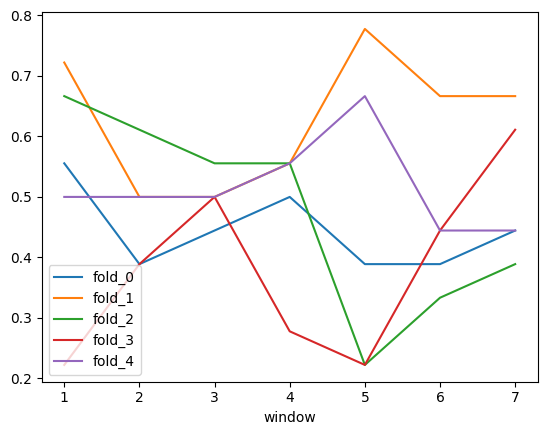

In [132]:
import matplotlib.pyplot as plt
for _ in range(len(fold_accuracies)):
    plt.plot([__ + 1 for __ in range(num_windows)], fold_accuracies[_].values(), label=f"fold_{_}")
plt.xlabel("window")
plt.legend()